In [13]:
import pandas as pd
import numpy as np
from lifelines import KaplanMeierFitter, CoxPHFitter
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2
from lifelines.statistics import multivariate_logrank_test,logrank_test


datos = pd.read_csv("Life_Device_P2.txt", sep="\t")

# Expansión de registros según número de dispositivos
datos_expandido = datos.loc[datos.index.repeat(datos["Devices"])].copy()
datos_expandido = datos_expandido[["Lower", "Upper", "Status", "Temperature"]]
datos_expandido["Evento"] = (datos_expandido["Status"] == "Failed").astype(int)



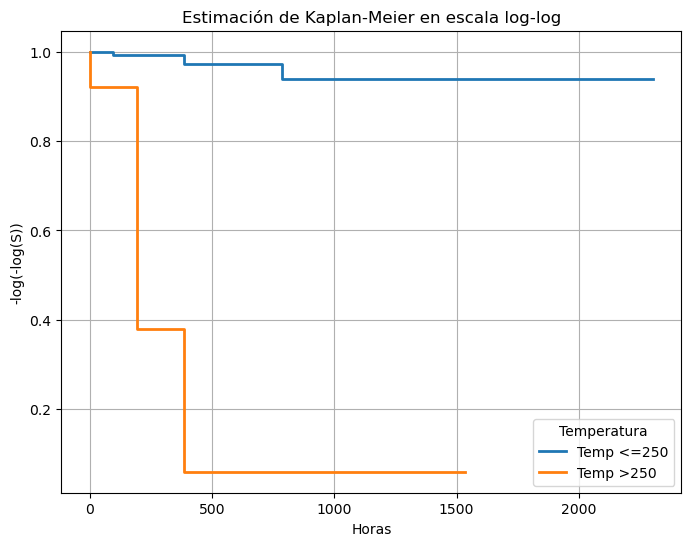

In [36]:
# Definir grupos
grupo_temp = (datos_expandido["Temperature"] > 250).astype(int)
datos_expandido["grupo_temp"] = grupo_temp


plt.figure(figsize=(8, 6))

for grupo, df_sub in datos_expandido.groupby("grupo_temp"):
    etiqueta = f'Temp {"<=250" if grupo == 0 else ">250"}'
    kmf.fit(df_sub["Lower"], df_sub["Evento"], label=etiqueta)
    surv_prob = kmf.survival_function_
    surv_prob_transf = -np.log(-np.log(surv_prob))

    plt.step(surv_prob.index, surv_prob.values.flatten(), label=etiqueta, lw=2)

plt.title("Estimación de Kaplan-Meier en escala log-log")
plt.xlabel("Horas")
plt.ylabel("-log(-log(S))")
plt.legend(title="Temperatura")
plt.grid(True)
plt.show()


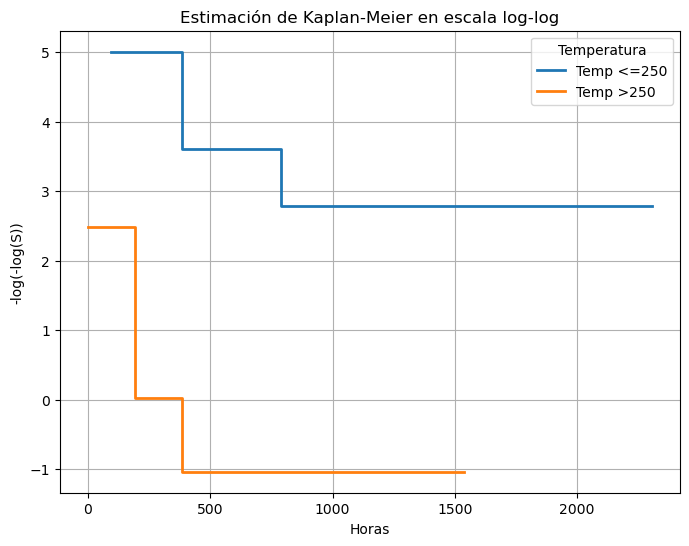

In [37]:
plt.figure(figsize=(8, 6))

for grupo, df_sub in datos_expandido.groupby("grupo_temp"):
    etiqueta = f'Temp {"<=250" if grupo == 0 else ">250"}'
    kmf.fit(df_sub["Lower"], df_sub["Evento"], label=etiqueta)
    surv_prob = kmf.survival_function_
    surv_prob_transf = -np.log(-np.log(surv_prob))

    plt.step(surv_prob_transf.index, surv_prob_transf.values.flatten(), label=etiqueta, lw=2)

plt.title("Estimación de Kaplan-Meier en escala log-log")
plt.xlabel("Horas")
plt.ylabel("-log(-log(S))")
plt.legend(title="Temperatura")
plt.grid(True)
plt.show()

In [38]:
grupo1 = datos_expandido[datos_expandido["grupo_temp"] == 0]
grupo2 = datos_expandido[datos_expandido["grupo_temp"] == 1]

logrank = logrank_test(grupo1["Lower"], grupo2["Lower"],
                       grupo1["Evento"], grupo2["Evento"])
print(logrank.summary)


   test_statistic             p    -log2(p)
0      201.268731  1.104004e-45  149.344019


In [39]:
# Ajustar modelo de Cox
cph = CoxPHFitter()
cph.fit(datos_expandido[["Lower", "Evento", "Temperature"]], duration_col="Lower", event_col="Evento")
cph.print_summary()


<lifelines.CoxPHFitter: fitted with 250 total observations, 194 right-censored observations>
             duration col = 'Lower'
                event col = 'Evento'
      baseline estimation = breslow
   number of observations = 250
number of events observed = 56
   partial log-likelihood = -198.88
         time fit was run = 2025-05-05 05:36:45 UTC

---
              coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                           
Temperature   0.06       1.06       0.01             0.04             0.07                 1.04                 1.08

              cmp to    z      p   -log2(p)
covariate                                  
Temperature     0.00 7.85 <0.005      47.76
---
Concordance = 0.50
Partial AIC = 399.76
log-likelihood ratio test = 178.59 on 1 df
-log2(p) of ll-ratio test = 132.90

In [40]:
coef = cph.params_["Temperature"]
se = cph.standard_errors_["Temperature"]
wald_stat = (coef / se)**2
p_val = 1 - chi2.cdf(wald_stat, df=1)
print("Estadístico de Wald:", wald_stat)
print("Valor-p:", p_val)


Estadístico de Wald: 61.60920522917446
Valor-p: 4.218847493575595e-15


In [41]:
# Modelo nulo
cph_nulo = CoxPHFitter()
cph_nulo.fit(datos_expandido[["Lower", "Evento"]], duration_col="Lower", event_col="Evento")

# Comparación de modelos
llr = 2 * (cph.log_likelihood_ - cph_nulo.log_likelihood_)
p_lrt = 1 - chi2.cdf(llr, df=1)
print(f"LRT = {llr:.4f}, p-valor = {p_lrt:.4f}")


LRT = 178.5918, p-valor = 0.0000


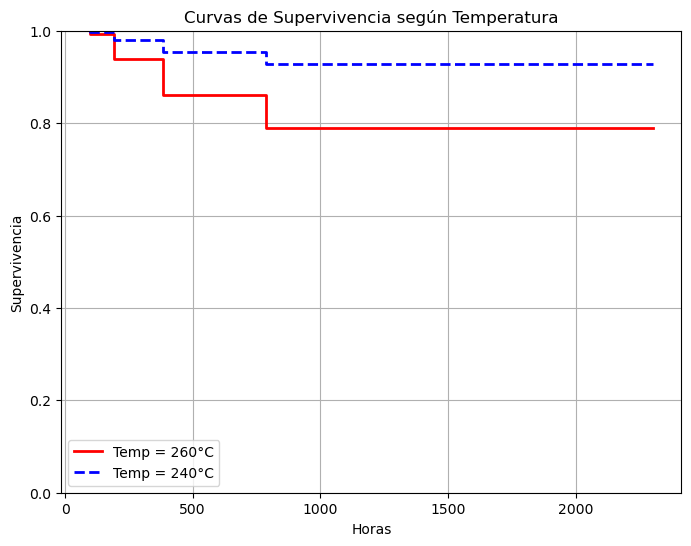

In [42]:
nuevo_mayor40 = pd.DataFrame({"Temperature": [260]})
nuevo_menor40 = pd.DataFrame({"Temperature": [240]})

s_mayor40 = cph.predict_survival_function(nuevo_mayor40)
s_menor40 = cph.predict_survival_function(nuevo_menor40)

plt.figure(figsize=(8, 6))
plt.step(s_mayor40.index, s_mayor40.values.flatten(), label="Temp = 260°C", color="red", lw=2)
plt.step(s_menor40.index, s_menor40.values.flatten(), label="Temp = 240°C", color="blue", lw=2, linestyle="--")

plt.title("Curvas de Supervivencia según Temperatura")
plt.xlabel("Horas")
plt.ylabel("Supervivencia")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()


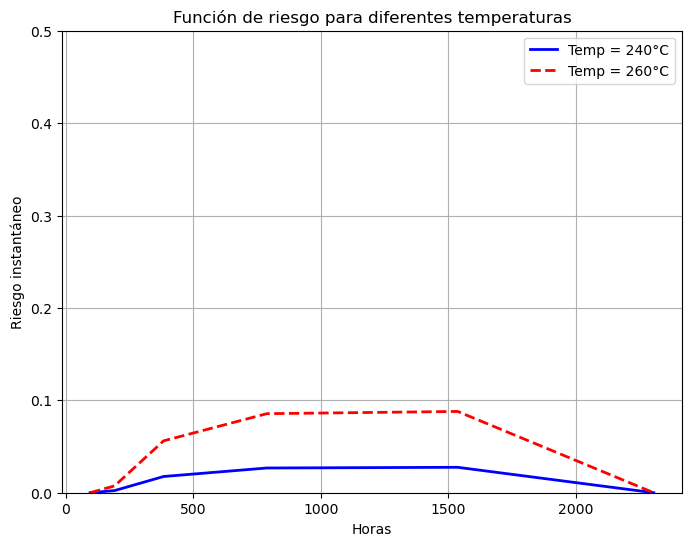

In [43]:
# Estimar la función de riesgo base (hazard)
base_haz = cph.baseline_hazard_

# Función para obtener riesgo para un valor de temperatura
def obtener_hazard(temp_val):
    rr = np.exp(cph.params_['Temperature'] * (temp_val - np.mean(datos_expandido["Temperature"])))
    base_vals = base_haz.values.ravel()  # Asegura vector 1D
    hazard = rr *  base_vals
    return pd.DataFrame({'time': base_haz.index, 'hazard': hazard})  

haz_menor240 = obtener_hazard(240)
haz_mayor260 = obtener_hazard(260)

plt.figure(figsize=(8, 6))
plt.plot(haz_menor240["time"], haz_menor240["hazard"], label="Temp = 240°C", color="blue", lw=2)
plt.plot(haz_mayor260["time"], haz_mayor260["hazard"], label="Temp = 260°C", color="red", lw=2, linestyle="--")

plt.title("Función de riesgo para diferentes temperaturas")
plt.xlabel("Horas")
plt.ylabel("Riesgo instantáneo")
plt.ylim(0, 0.5)
plt.legend()
plt.grid(True)
plt.show()


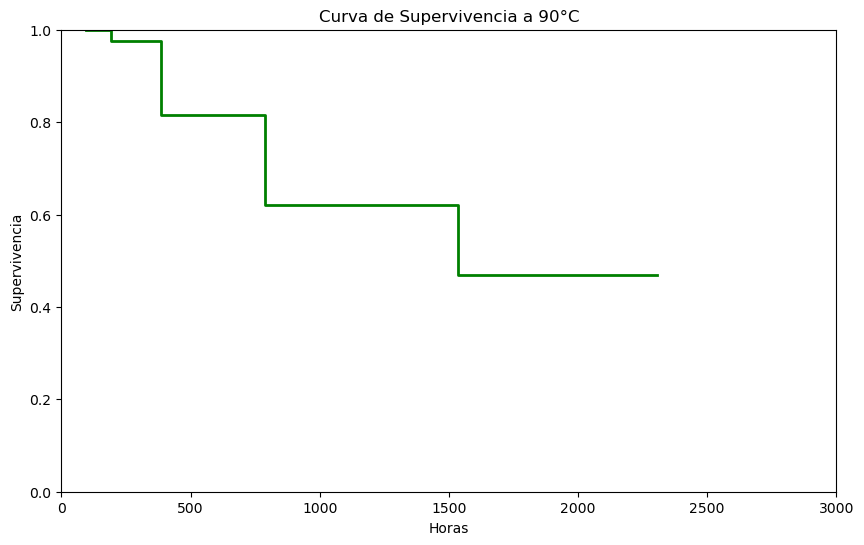

In [44]:


# Para una temperatura de 90°C
nuevo = pd.DataFrame({'Temperature': [280]})
s_base = cph.predict_survival_function(nuevo)

# Graficar la curva de supervivencia a 90°C
plt.figure(figsize=(10, 6))
#plt.plot(s_base.index, s_base[0], color="green", lw=2)
plt.step(s_base.index, s_base.iloc[:, 0], where="post", color="green", lw=2)
plt.xlim(0, 3000)
plt.title("Curva de Supervivencia a 90°C")
plt.xlabel("Horas")
plt.ylabel("Supervivencia")
plt.ylim(0,1)
plt.show()